In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [ ]:
base = Path(".")

seq = pd.read_csv(base / "sequential.csv")
rnd = pd.read_csv(base / "random.csv")
rnd_pre = pd.read_csv(base / "random_precomputed.csv")

seq["mode"] = "sequential"
rnd["mode"] = "random"
rnd_pre["mode"] = "random_precomputed"

df = pd.concat([seq, rnd, rnd_pre], ignore_index=True)

for name, part in [("sequential", seq), ("random", rnd), ("random_precomputed", rnd_pre)]:
    print(name, part.shape)
    display(part.head())

In [ ]:
def prepare_df(x: pd.DataFrame) -> pd.DataFrame:
    x = x.copy()
    x = x.sort_values("size_bytes").reset_index(drop=True)
    x["size_kb"] = x["size_bytes"] / 1024.0
    x["size_mb"] = x["size_bytes"] / (1024.0 * 1024.0)
    x["smooth"] = x["cycles_per_iteration"].rolling(window=21, center=True, min_periods=1).median()
    return x


seq_p = prepare_df(seq)
rnd_p = prepare_df(rnd)
rnd_pre_p = prepare_df(rnd_pre)

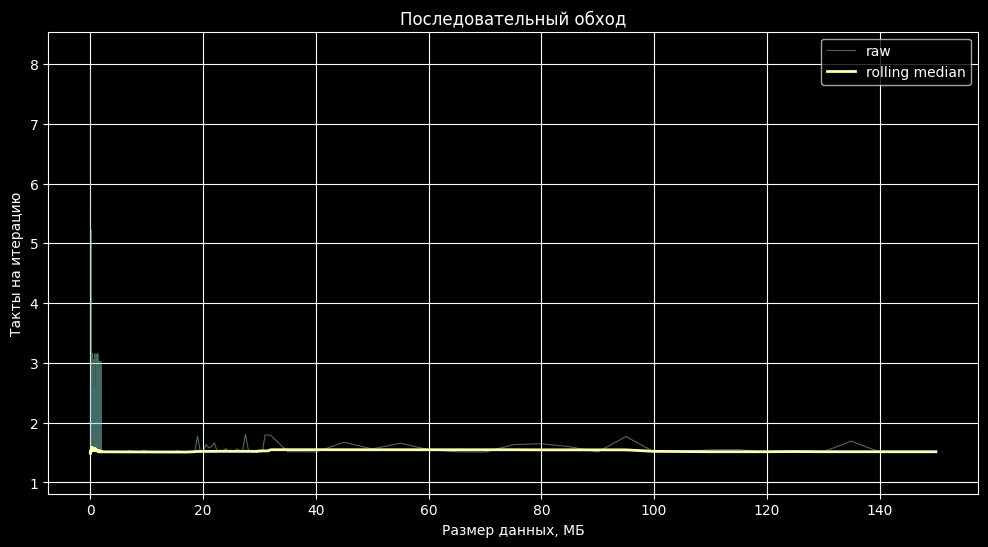

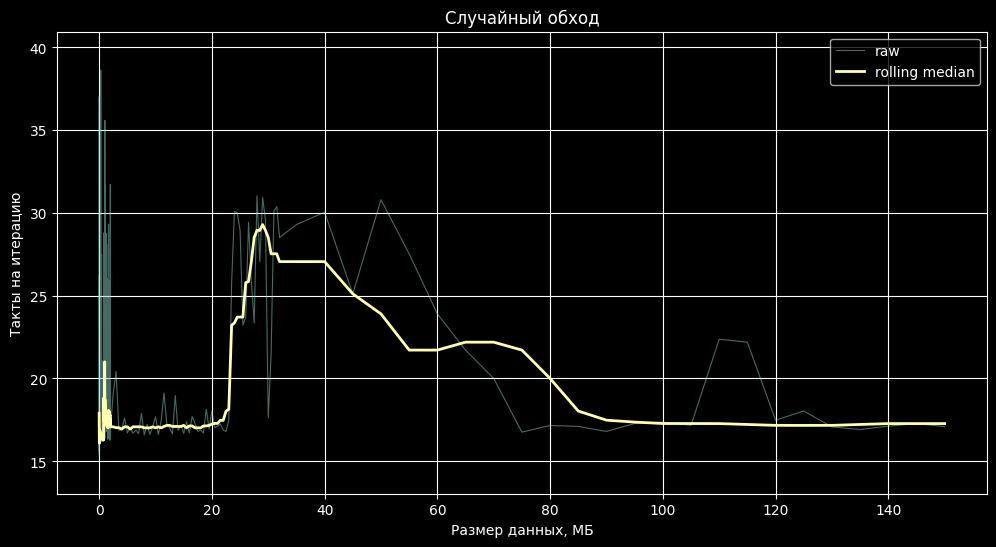

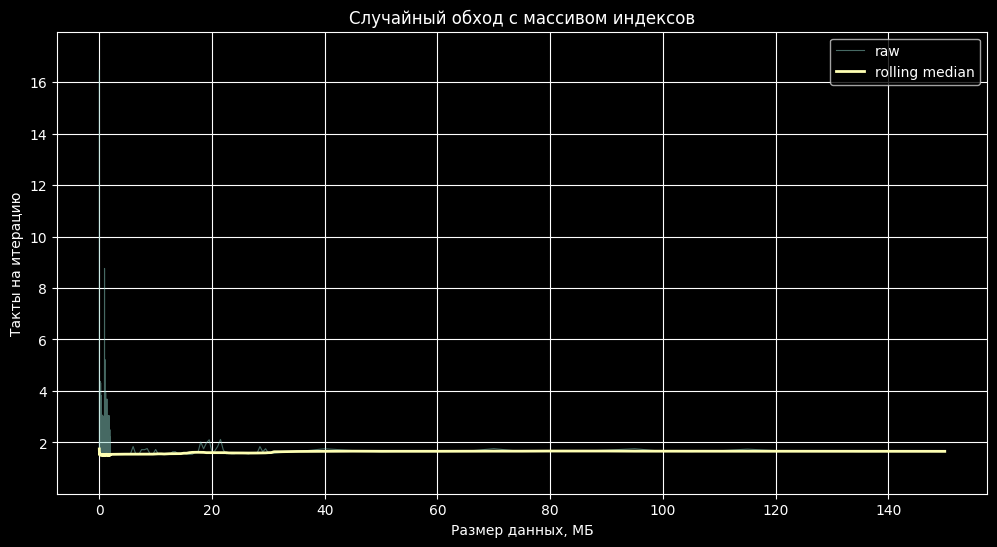

In [16]:
def plot_mode(data: pd.DataFrame, title: str, y_margin=0.1):
    plt.figure(figsize=(12, 6))

    y_raw = data["cycles_per_iteration"]
    y_smooth = data["smooth"]

    y_min = min(y_raw.min(), y_smooth.min())
    y_max = max(y_raw.max(), y_smooth.max())
    dy = y_max - y_min
    if dy == 0:
        dy = 1.0

    plt.plot(data["size_mb"], y_raw, linewidth=0.8, alpha=0.5, label="raw")
    plt.plot(data["size_mb"], y_smooth, linewidth=2.0, label="rolling median")

    plt.ylim(y_min - y_margin * dy, y_max + y_margin * dy)
    plt.xlabel("Размер данных, МБ")
    plt.ylabel("Такты на итерацию")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_mode(seq_p, "Последовательный обход")
plot_mode(rnd_p, "Случайный обход")
plot_mode(rnd_pre_p, "Случайный обход с массивом индексов")

In [ ]:
plt.figure(figsize=(13, 7))
plt.plot(seq_p["size_mb"], seq_p["smooth"], label="sequential", linewidth=2)
plt.plot(rnd_p["size_mb"], rnd_p["smooth"], label="random", linewidth=2)
plt.plot(rnd_pre_p["size_mb"], rnd_pre_p["smooth"], label="random_precomputed", linewidth=2)

plt.xlabel("Размер данных, МБ")
plt.ylabel("Такты на итерацию")
plt.title("Сравнение режимов обхода")
plt.legend()
plt.show()

In [ ]:
def plot_mode_logx(data: pd.DataFrame, title: str):
    plt.figure()
    plt.plot(data["size_kb"], data["cycles_per_iteration"], linewidth=0.8, alpha=0.5, label="raw")
    plt.plot(data["size_kb"], data["smooth"], linewidth=2.0, label="rolling median")
    plt.xscale("log")
    plt.xlabel("Размер данных, КБ (log scale)")
    plt.ylabel("Такты на итерацию")
    plt.title(title)
    plt.legend()
    plt.show()


plot_mode_logx(seq_p, "Последовательный обход")
plot_mode_logx(rnd_p, "Случайный обход")
plot_mode_logx(rnd_pre_p, "Случайный обход с массивом индексов")

In [ ]:
CPU_NAME = "AMD Ryzen 9 9950X"

REGIONS = {
    "sequential": {
        "effective": (128, 150 * 1024)
    },
    "random": {
        "L1":  (1, 32),
        "L2":  (40, 1024),
        "L3":  (2048, 64 * 1024),
        "RAM": (70 * 1024, 150 * 1024),
    },
    "random_precomputed": {
        "L1":  (1, 16),
        "L2":  (24, 512),
        "L3":  (1024, 32 * 1024),
        "RAM": (40 * 1024, 150 * 1024),
    }
}

In [ ]:
def estimate_region_latency(data: pd.DataFrame, left_kb: float, right_kb: float, use_smooth=True):
    col = "smooth" if use_smooth else "cycles_per_iteration"
    part = data[(data["size_kb"] >= left_kb) & (data["size_kb"] <= right_kb)].copy()
    if part.empty:
        return np.nan
    return part[col].median()


def build_latency_table(seq_data, rnd_data, rnd_pre_data, regions):
    rows = []

    seq_est = {}
    for region_name, bounds in regions["sequential"].items():
        seq_est[region_name] = estimate_region_latency(seq_data, bounds[0], bounds[1])

    rnd_est = {}
    for region_name, bounds in regions["random"].items():
        rnd_est[region_name] = estimate_region_latency(rnd_data, bounds[0], bounds[1])

    rnd_pre_est = {}
    for region_name, bounds in regions["random_precomputed"].items():
        rnd_pre_est[region_name] = estimate_region_latency(rnd_pre_data, bounds[0], bounds[1])

    rows.append({
        "mode": "sequential",
        "effective": seq_est.get("effective", np.nan),
        "L1": np.nan,
        "L2": np.nan,
        "L3": np.nan,
        "RAM": np.nan
    })

    rows.append({
        "mode": "random",
        "effective": np.nan,
        "L1": rnd_est.get("L1", np.nan),
        "L2": rnd_est.get("L2", np.nan),
        "L3": rnd_est.get("L3", np.nan),
        "RAM": rnd_est.get("RAM", np.nan)
    })

    rows.append({
        "mode": "random_precomputed",
        "effective": np.nan,
        "L1": rnd_pre_est.get("L1", np.nan),
        "L2": rnd_pre_est.get("L2", np.nan),
        "L3": rnd_pre_est.get("L3", np.nan),
        "RAM": rnd_pre_est.get("RAM", np.nan)
    })

    return pd.DataFrame(rows)


latency_table = build_latency_table(seq_p, rnd_p, rnd_pre_p, REGIONS)
latency_table

In [ ]:
REFERENCE = {
    "Intel Atom N270": {
        "sequential": {"effective": "29"},
        "random": {"L1": "25-30", "L2": "45-55", "L3": "-", "RAM": "240-340"},
        "random_precomputed": {"L1": "6", "L2": "26", "L3": "-", "RAM": "до 210"},
    },
    "Intel Core i7 4770": {
        "sequential": {"effective": "8-9"},
        "random": {"L1": "9", "L2": "9", "L3": "14-16", "RAM": "до 106"},
        "random_precomputed": {"L1": "1", "L2": "2-5", "L3": "10-24", "RAM": "до 100"},
    },
    "AMD Ryzen 7 7700": {
        "sequential": {"effective": "7-8"},
        "random": {"L1": "7", "L2": "7", "L3": "7-18", "RAM": "23"},
        "random_precomputed": {"L1": "1", "L2": "1-2", "L3": "2-10", "RAM": "до 16"},
    }
}

In [ ]:
REFERENCE_CPU = "Intel Core i7 4770"   # измени при необходимости

ref_rows = [
    {
        "mode": "sequential",
        "effective_ref": REFERENCE[REFERENCE_CPU]["sequential"]["effective"],
        "L1_ref": "",
        "L2_ref": "",
        "L3_ref": "",
        "RAM_ref": "",
    },
    {
        "mode": "random",
        "effective_ref": "",
        "L1_ref": REFERENCE[REFERENCE_CPU]["random"]["L1"],
        "L2_ref": REFERENCE[REFERENCE_CPU]["random"]["L2"],
        "L3_ref": REFERENCE[REFERENCE_CPU]["random"]["L3"],
        "RAM_ref": REFERENCE[REFERENCE_CPU]["random"]["RAM"],
    },
    {
        "mode": "random_precomputed",
        "effective_ref": "",
        "L1_ref": REFERENCE[REFERENCE_CPU]["random_precomputed"]["L1"],
        "L2_ref": REFERENCE[REFERENCE_CPU]["random_precomputed"]["L2"],
        "L3_ref": REFERENCE[REFERENCE_CPU]["random_precomputed"]["L3"],
        "RAM_ref": REFERENCE[REFERENCE_CPU]["random_precomputed"]["RAM"],
    }
]

ref_df = pd.DataFrame(ref_rows)

comparison = latency_table.merge(ref_df, on="mode", how="left")
comparison

In [ ]:
def fmt(x):
    if pd.isna(x):
        return "—"
    return f"{x:.2f}"

seq_eff = latency_table.loc[latency_table["mode"] == "sequential", "effective"].iloc[0]

rnd_row = latency_table[latency_table["mode"] == "random"].iloc[0]
pre_row = latency_table[latency_table["mode"] == "random_precomputed"].iloc[0]

summary_text = f"""
Система: {CPU_NAME}

1. Для последовательного обхода получена эффективная задержка порядка {fmt(seq_eff)} такта(ов) на итерацию.
   Этот режим показывает минимальные значения, так как последовательный доступ хорошо использует кэш-линии
   и аппаратную предвыборку данных.

2. Для случайного обхода наблюдаются характерные ступени на графике:
   L1 ≈ {fmt(rnd_row["L1"])},
   L2 ≈ {fmt(rnd_row["L2"])},
   L3 ≈ {fmt(rnd_row["L3"])},
   RAM ≈ {fmt(rnd_row["RAM"])} такта(ов) на итерацию.

3. Для случайного обхода с дополнительным массивом индексов получены оценки:
   L1 ≈ {fmt(pre_row["L1"])},
   L2 ≈ {fmt(pre_row["L2"])},
   L3 ≈ {fmt(pre_row["L3"])},
   RAM ≈ {fmt(pre_row["RAM"])} такта(ов) на итерацию.

4. По сравнению с обычным случайным обходом режим с готовым массивом индексов лучше отражает собственно
   латентность памяти, так как из рабочего цикла убрана генерация случайного индекса. При этом дополнительный
   массив индексов увеличивает рабочий набор и может уменьшать эффективный объём кэша.

5. Переходы между уровнями памяти на графиках видны как скачки времени на итерацию при росте размера данных.
   После превышения ёмкости кэша очередного уровня время доступа возрастает.
"""

print(summary_text)

In [ ]:
latency_table.to_csv("latency_table_estimated.csv", index=False)
comparison.to_csv("latency_table_comparison.csv", index=False)

print("Сохранено:")
print(" - latency_table_estimated.csv")
print(" - latency_table_comparison.csv")